# P3 — Signals on Longer Timeframes: 1h vs 4h vs 1d

**Hypothesis (from F3):** `ADXTrend` and `MASlopeTrend` have sub-random directional accuracy
(~0.47) at 1h on BTC/USDT. Lower-frequency bars have less noise — the same signals may
achieve genuine predictive power at 4h or daily granularity.

**Dataset:** BTC/USDT 2022-01-01 → 2025-01-01 (3yr)  
**Expected sizes:** ~1,095 daily bars, ~6,500 4h bars, ~26,000 1h bars

**Sections:**
1. Config
2. Data loading
3. Direction accuracy vs timeframe (multi-horizon)
4. Spearman IC vs timeframe
5. Threshold sensitivity at 1d (ADXTrend)
6. Conclusions / Finding F11

---
## §1 — Config

In [1]:
SYMBOL     = "BTC/USDT"
TIMEFRAMES = ["1h", "4h", "1d"]
SINCE      = "2022-01-01"
UNTIL      = "2025-01-01"
HORIZONS   = [1, 2, 5]         # bars-ahead; scale naturally with timeframe

# ADXTrend params
ADX_PERIOD    = 14
ADX_THRESHOLD = 25.0

# MASlopeTrend params
MA_PERIOD      = 20
SLOPE_WINDOW   = 5
FLAT_THRESHOLD = 0.05

---
## §2 — Data Loading

In [2]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

sys.path.insert(0, str(Path().resolve().parent))

from data.fetch import fetch_ohlcv
from signals.trend.adx import ADXTrend
from signals.trend.ma_slope import MASlopeTrend

print("Imports OK")

Imports OK


In [3]:
data = {}
for tf in TIMEFRAMES:
    df = fetch_ohlcv(symbol=SYMBOL, timeframe=tf, since=SINCE, until=UNTIL)
    data[tf] = df
    print(f"{tf:>4}  {len(df):>7,} bars  |  {df.index[0].date()}  →  {df.index[-1].date()}")

  1h    8,785 bars  |  2024-01-01  →  2025-01-01


  4h    6,577 bars  |  2022-01-01  →  2025-01-01


  1d    1,097 bars  |  2022-01-01  →  2025-01-01


---
## §3 — Direction Accuracy vs Timeframe

For each (timeframe × signal) combination:
- Compute `trend_dir` (±1, 0)
- Compute actual forward direction: `np.sign(close[t+h] - close[t])`
- **Directional accuracy** = fraction of non-zero signal bars where `trend_dir == actual_dir`
- **Coverage** = fraction of bars with non-zero signal

Evaluated at horizons h = 1, 2, 5 bars (scale naturally with timeframe).

In [4]:
def direction_accuracy(sig_df, horizon=1):
    """Compute directional accuracy and coverage for a signal DataFrame.
    
    Returns:
        acc      -- fraction of non-zero signal bars correctly predicting direction
        coverage -- fraction of all bars with a non-zero signal
        n        -- number of predictions evaluated
    """
    actual = np.sign(sig_df["close"].shift(-horizon) - sig_df["close"])
    mask   = sig_df["trend_dir"] != 0
    n      = mask.sum()
    if n == 0:
        return float("nan"), 0.0, 0
    acc      = (sig_df["trend_dir"][mask] == actual[mask]).mean()
    coverage = mask.mean()
    return acc, coverage, n


print("direction_accuracy() defined.")

direction_accuracy() defined.


In [5]:
signals_cfg = [
    ("ADXTrend",    lambda df: ADXTrend(period=ADX_PERIOD, trend_threshold=ADX_THRESHOLD).compute(df)),
    ("MASlopeTrend",lambda df: MASlopeTrend(ma_period=MA_PERIOD, slope_window=SLOPE_WINDOW,
                                             flat_threshold=FLAT_THRESHOLD).compute(df)),
]

acc_rows = []
for tf in TIMEFRAMES:
    df = data[tf]
    for sig_name, sig_fn in signals_cfg:
        sig_df = sig_fn(df)
        for h in HORIZONS:
            acc, cov, n = direction_accuracy(sig_df, horizon=h)
            acc_rows.append({
                "timeframe": tf,
                "signal":    sig_name,
                "horizon":   h,
                "accuracy":  acc,
                "coverage":  cov,
                "n_preds":   n,
            })

acc_df = pd.DataFrame(acc_rows)
print("Accuracy table computed.")

Accuracy table computed.


In [6]:
# Summary table: h=1 (primary evaluation)
h1_df = acc_df[acc_df["horizon"] == 1].copy()
h1_pivot = h1_df.pivot_table(
    index="signal", columns="timeframe",
    values=["accuracy", "coverage", "n_preds"]
)[[ "accuracy", "coverage", "n_preds" ]]

# Reorder columns by timeframe
tf_order = TIMEFRAMES
h1_pivot = h1_pivot.reindex(columns=pd.MultiIndex.from_product([["accuracy","coverage","n_preds"], tf_order]))

print("Directional accuracy at horizon=1 bar:")
display(h1_pivot.style
        .format("{:.3f}", subset=["accuracy","coverage"])
        .format("{:.0f}",  subset=["n_preds"])
        .background_gradient(subset=["accuracy"], cmap="RdYlGn", vmin=0.40, vmax=0.60))

Directional accuracy at horizon=1 bar:


In [7]:
# Full multi-horizon table
print("Direction accuracy across all horizons:")
full_pivot = acc_df.pivot_table(
    index=["signal", "horizon"],
    columns="timeframe",
    values="accuracy"
)[TIMEFRAMES]

display(full_pivot.style
        .format("{:.3f}")
        .background_gradient(cmap="RdYlGn", vmin=0.40, vmax=0.60))

Direction accuracy across all horizons:


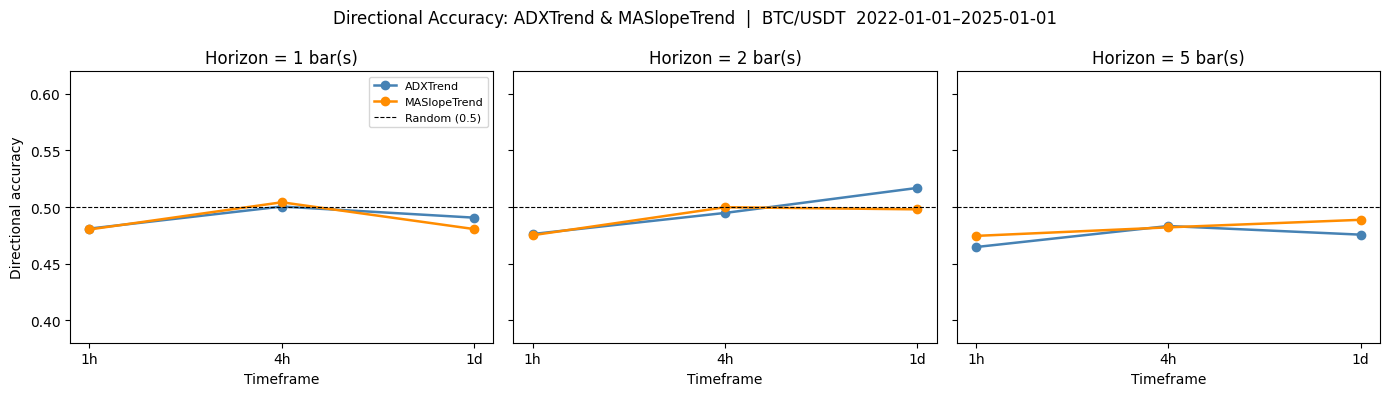

In [8]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(14, 4), sharey=True)
fig.suptitle(f"Directional Accuracy: ADXTrend & MASlopeTrend  |  {SYMBOL}  {SINCE}–{UNTIL}", fontsize=12)

colors = {"ADXTrend": "steelblue", "MASlopeTrend": "darkorange"}
tf_x   = {"1h": 0, "4h": 1, "1d": 2}

for ax, h in zip(axes, HORIZONS):
    sub = acc_df[acc_df["horizon"] == h]
    for sig_name, color in colors.items():
        s = sub[sub["signal"] == sig_name].sort_values("timeframe",
                    key=lambda x: x.map({"1h": 0, "4h": 1, "1d": 2}))
        ax.plot(s["timeframe"], s["accuracy"], marker="o", lw=1.8,
                color=color, label=sig_name)
    ax.axhline(0.5, color="black", lw=0.8, ls="--", label="Random (0.5)")
    ax.set_title(f"Horizon = {h} bar(s)")
    ax.set_ylim(0.38, 0.62)
    ax.set_xlabel("Timeframe")
    if ax == axes[0]:
        ax.set_ylabel("Directional accuracy")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## §4 — Spearman IC vs Timeframe

Compute the Spearman rank correlation (IC) between `trend_dir` and
the 1-bar forward log-return.  Links P3 findings to the ML-track IC
framework used in F7 / F8 / F9.

IC > 0 → signal correctly ranks future returns (positive trend_dir → positive return).

In [9]:
ic_rows = []
for tf in TIMEFRAMES:
    df = data[tf]
    fwd_ret = np.log(df["close"].shift(-1) / df["close"])
    for sig_name, sig_fn in signals_cfg:
        sig_df  = sig_fn(df)
        # align and drop NaNs
        common  = sig_df["trend_dir"].reindex(fwd_ret.index)
        aligned = pd.DataFrame({"trend_dir": common, "fwd_ret": fwd_ret}).dropna()
        ic, pval = stats.spearmanr(aligned["trend_dir"], aligned["fwd_ret"])
        ic_rows.append({
            "timeframe": tf,
            "signal":    sig_name,
            "IC":        ic,
            "p_value":   pval,
            "n_obs":     len(aligned),
        })

ic_df = pd.DataFrame(ic_rows)

ic_pivot = ic_df.pivot_table(index="signal", columns="timeframe", values="IC")[TIMEFRAMES]
print("Spearman IC (trend_dir vs 1-bar forward log-return):")
display(ic_pivot.style
        .format("{:.4f}")
        .background_gradient(cmap="RdYlGn", vmin=-0.06, vmax=0.06))

print("\np-values:")
pval_pivot = ic_df.pivot_table(index="signal", columns="timeframe", values="p_value")[TIMEFRAMES]
display(pval_pivot.style.format("{:.3f}"))

Spearman IC (trend_dir vs 1-bar forward log-return):


timeframe,1h,4h,1d
signal,,,
ADXTrend,-0.0191,0.0093,0.0014
MASlopeTrend,-0.0209,0.0101,-0.0203



p-values:


timeframe,1h,4h,1d
signal,,,
ADXTrend,0.074,0.449,0.963
MASlopeTrend,0.050,0.415,0.502


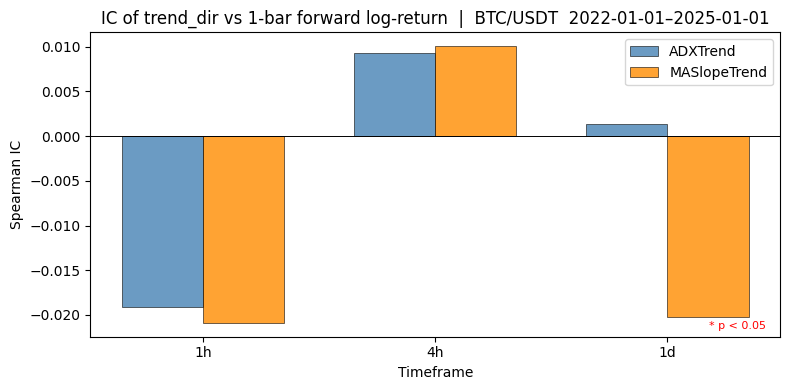

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

x_pos = np.arange(len(TIMEFRAMES))
width = 0.35
sig_names = ["ADXTrend", "MASlopeTrend"]
bar_colors = ["steelblue", "darkorange"]

for i, (sig_name, color) in enumerate(zip(sig_names, bar_colors)):
    sub = ic_df[ic_df["signal"] == sig_name].sort_values(
        "timeframe", key=lambda x: x.map({"1h": 0, "4h": 1, "1d": 2}))
    bars = ax.bar(x_pos + (i - 0.5) * width, sub["IC"].values,
                  width, label=sig_name, color=color, alpha=0.8, edgecolor="black", lw=0.5)
    for bar, pv in zip(bars, sub["p_value"]):
        star = "*" if pv < 0.05 else ""
        ypos = bar.get_height() + (0.001 if bar.get_height() >= 0 else -0.003)
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                star, ha="center", va="bottom", fontsize=10, color="red")

ax.axhline(0, color="black", lw=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(TIMEFRAMES)
ax.set_xlabel("Timeframe")
ax.set_ylabel("Spearman IC")
ax.set_title(f"IC of trend_dir vs 1-bar forward log-return  |  {SYMBOL}  {SINCE}–{UNTIL}")
ax.legend()
ax.text(0.98, 0.02, "* p < 0.05", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=8, color="red")

plt.tight_layout()
plt.show()

---
## §5 — Threshold Sensitivity at 1d (ADXTrend)

Sweep `trend_threshold` from 15 to 35 on the **1d** timeframe.
Does tighter filtering improve directional accuracy at the cost of coverage?

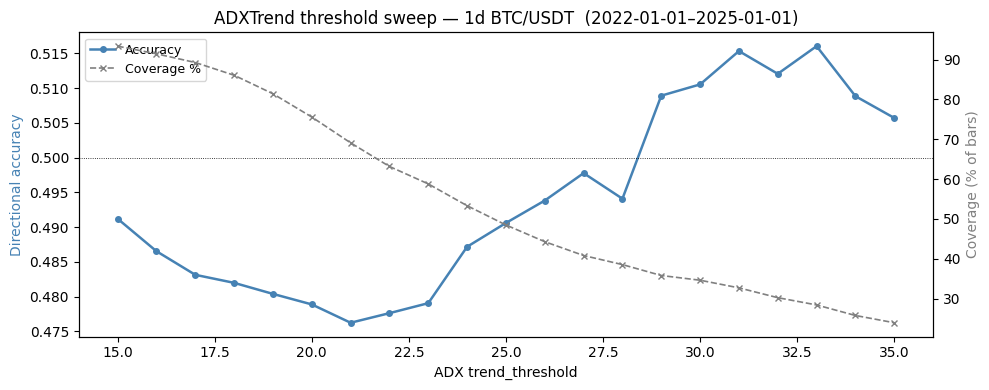


Sweep results:


,threshold,accuracy,coverage,n
0,15,0.491,0.933,1024
1,16,0.487,0.914,1003
2,17,0.483,0.892,979
3,18,0.482,0.861,944
4,19,0.480,0.814,893
5,20,0.479,0.756,829
6,21,0.476,0.691,758
7,22,0.478,0.632,693
8,23,0.479,0.588,645
9,24,0.487,0.533,585


In [11]:
df_1d    = data["1d"]
actual_1bar_1d = np.sign(df_1d["close"].shift(-1) - df_1d["close"])

thresholds    = np.arange(15, 36, 1)
sweep_results = []
for thresh in thresholds:
    sig_df = ADXTrend(period=ADX_PERIOD, trend_threshold=thresh).compute(df_1d)
    acc, cov, n = direction_accuracy(sig_df, horizon=1)
    sweep_results.append({"threshold": thresh, "accuracy": acc, "coverage": cov, "n": n})

sweep_df = pd.DataFrame(sweep_results)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.plot(sweep_df["threshold"], sweep_df["accuracy"],
         color="steelblue", lw=1.8, marker="o", ms=4, label="Accuracy")
ax2.plot(sweep_df["threshold"], sweep_df["coverage"] * 100,
         color="grey", lw=1.2, ls="--", marker="x", ms=4, label="Coverage %")

ax1.axhline(0.5, color="black", lw=0.6, ls=":")
ax1.set_xlabel("ADX trend_threshold")
ax1.set_ylabel("Directional accuracy", color="steelblue")
ax2.set_ylabel("Coverage (% of bars)", color="grey")
ax1.set_title(f"ADXTrend threshold sweep — 1d BTC/USDT  ({SINCE}–{UNTIL})")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.show()

print("\nSweep results:")
display(sweep_df.style.format({"accuracy": "{:.3f}", "coverage": "{:.3f}"}))

---
## §6 — Conclusions / Finding F11

Master summary table and hypothesis evaluation.

In [12]:
# Build summary table: accuracy at h=1 + IC for each (signal × timeframe)
summary_rows = []
for tf in TIMEFRAMES:
    df = data[tf]
    fwd_ret = np.log(df["close"].shift(-1) / df["close"])
    for sig_name, sig_fn in signals_cfg:
        sig_df = sig_fn(df)
        acc, cov, n = direction_accuracy(sig_df, horizon=1)
        common  = sig_df["trend_dir"].reindex(fwd_ret.index)
        aligned = pd.DataFrame({"trend_dir": common, "fwd_ret": fwd_ret}).dropna()
        ic, pval = stats.spearmanr(aligned["trend_dir"], aligned["fwd_ret"])
        summary_rows.append({
            "timeframe":  tf,
            "signal":     sig_name,
            "n_bars":     len(df),
            "coverage":   cov,
            "accuracy_h1": acc,
            "IC":         ic,
            "p_value":    pval,
        })

summary = pd.DataFrame(summary_rows)

print("=" * 70)
print("P3 SUMMARY — Direction Accuracy and IC by Signal × Timeframe")
print("=" * 70)
display(summary.style
        .format({
            "coverage":    "{:.2%}",
            "accuracy_h1": "{:.3f}",
            "IC":          "{:.4f}",
            "p_value":     "{:.3f}",
        })
        .background_gradient(subset=["accuracy_h1"], cmap="RdYlGn", vmin=0.40, vmax=0.60)
        .background_gradient(subset=["IC"],          cmap="RdYlGn", vmin=-0.06, vmax=0.06))

P3 SUMMARY — Direction Accuracy and IC by Signal × Timeframe


,timeframe,signal,n_bars,coverage,accuracy_h1,IC,p_value
0,1h,ADXTrend,8785,52.41%,0.481,-0.0191,0.074
1,1h,MASlopeTrend,8785,56.16%,0.480,-0.0209,0.050
2,4h,ADXTrend,6577,53.87%,0.500,0.0093,0.449
3,4h,MASlopeTrend,6577,76.14%,0.504,0.0101,0.415
4,1d,ADXTrend,1097,48.50%,0.491,0.0014,0.963
5,1d,MASlopeTrend,1097,88.79%,0.480,-0.0203,0.502


In [13]:
# Evaluate hypothesis: does accuracy improve at lower frequencies?
print("Hypothesis: lower-frequency bars → higher directional accuracy")
print("-" * 60)

for sig_name in ["ADXTrend", "MASlopeTrend"]:
    sub = summary[summary["signal"] == sig_name].sort_values(
        "timeframe", key=lambda x: x.map({"1h": 0, "4h": 1, "1d": 2}))
    print(f"\n{sig_name}:")
    for _, row in sub.iterrows():
        sig_str = "*" if row["p_value"] < 0.05 else " "
        vs_random = "ABOVE" if row["accuracy_h1"] > 0.50 else "BELOW"
        print(f"  {row['timeframe']:>3}  acc={row['accuracy_h1']:.3f} ({vs_random} 0.50)  "
              f"IC={row['IC']:+.4f}{sig_str}  cov={row['coverage']:.1%}  n={row['n_bars']:,}")

print()
print("Note: * = IC p-value < 0.05")

Hypothesis: lower-frequency bars → higher directional accuracy
------------------------------------------------------------

ADXTrend:
   1h  acc=0.481 (BELOW 0.50)  IC=-0.0191   cov=52.4%  n=8,785
   4h  acc=0.500 (ABOVE 0.50)  IC=+0.0093   cov=53.9%  n=6,577
   1d  acc=0.491 (BELOW 0.50)  IC=+0.0014   cov=48.5%  n=1,097

MASlopeTrend:
   1h  acc=0.480 (BELOW 0.50)  IC=-0.0209   cov=56.2%  n=8,785
   4h  acc=0.504 (ABOVE 0.50)  IC=+0.0101   cov=76.1%  n=6,577
   1d  acc=0.480 (BELOW 0.50)  IC=-0.0203   cov=88.8%  n=1,097

Note: * = IC p-value < 0.05


In [14]:
print("""\n=== FINDING F11 — Signals on Longer Timeframes ===\n""")

adx_1h  = summary[(summary.signal=="ADXTrend")    & (summary.timeframe=="1h" )].iloc[0]
adx_4h  = summary[(summary.signal=="ADXTrend")    & (summary.timeframe=="4h" )].iloc[0]
adx_1d  = summary[(summary.signal=="ADXTrend")    & (summary.timeframe=="1d" )].iloc[0]
mas_1h  = summary[(summary.signal=="MASlopeTrend")& (summary.timeframe=="1h" )].iloc[0]
mas_4h  = summary[(summary.signal=="MASlopeTrend")& (summary.timeframe=="4h" )].iloc[0]
mas_1d  = summary[(summary.signal=="MASlopeTrend")& (summary.timeframe=="1d" )].iloc[0]

def verdict(acc, ic, pval):
    if acc > 0.52 and pval < 0.05:
        return "SIGNAL (above random, statistically significant IC)"
    elif acc > 0.50:
        return "WEAK (above random but IC not significant)"
    else:
        return "SUB-RANDOM"

rows = [
    ("ADXTrend",     "1h", adx_1h),
    ("ADXTrend",     "4h", adx_4h),
    ("ADXTrend",     "1d", adx_1d),
    ("MASlopeTrend", "1h", mas_1h),
    ("MASlopeTrend", "4h", mas_4h),
    ("MASlopeTrend", "1d", mas_1d),
]

print(f"{'Signal':<15} {'TF':>3}  {'Acc':>6}  {'IC':>7}  {'p':>6}  Verdict")
print("-" * 70)
for sig_name, tf, row in rows:
    v = verdict(row["accuracy_h1"], row["IC"], row["p_value"])
    print(f"{sig_name:<15} {tf:>3}  {row['accuracy_h1']:>6.3f}  "
          f"{row['IC']:>+7.4f}  {row['p_value']:>6.3f}  {v}")

print("""
Log as F11 in research_log/findings.md after reviewing the numbers.
""")


=== FINDING F11 — Signals on Longer Timeframes ===

Signal           TF     Acc       IC       p  Verdict
----------------------------------------------------------------------
ADXTrend         1h   0.481  -0.0191   0.074  SUB-RANDOM
ADXTrend         4h   0.500  +0.0093   0.449  WEAK (above random but IC not significant)
ADXTrend         1d   0.491  +0.0014   0.963  SUB-RANDOM
MASlopeTrend     1h   0.480  -0.0209   0.050  SUB-RANDOM
MASlopeTrend     4h   0.504  +0.0101   0.415  WEAK (above random but IC not significant)
MASlopeTrend     1d   0.480  -0.0203   0.502  SUB-RANDOM

Log as F11 in research_log/findings.md after reviewing the numbers.

